# Classification with neural networks

In this notebook, you will build your first neural network, and apply it to cat vs non-cat classification. You will learn how to:
- Build a neural network with Keras (a high-level API written in Python),
- Apply a neural network to binary classification, in the context of supervised learning.

*Why are we using Keras?* Keras was developed to enable deep learning engineers to build and experiment with different models very quickly. Being able to go from idea to result with the least possible delay is key to finding good models. However, Keras is more restrictive than the lower-level frameworks, so there are some very complex models that you can implement in Autograd or Pytorch, but not (without more difficulty) in Keras. That being said, Keras will work fine for many common models.

# 1 - Required packages

Let's first import all the packages that you will need during this assignment.
- [Numpy](www.numpy.org) - The fundamental package for scientific computing with Python.
- [Matplotlib](http://matplotlib.org) - Library for plotting graphs in Python.
- [Scikit-Learn](http://scikit-learn.org/stable/) - Library for data mining and machine learning.
- [Keras](https://keras.io) High-level API for building neural networks in Python. 

*Run the following cell.*

---

**Installation:** Keras is not included in the standard Python installation. Open the terminal (Anaconda prompt on Windows) and execute the command:

```
pip install tensorflow
```

If you are not the admin, add the flag `--user` for a local installation, and **restart the notebook**.

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# 2 - Beyond linear models

The following code will generate a 2-class dataset into variables `X` and `Y`.

In [7]:
C = 50

X1 = np.random.multivariate_normal([0,0], 0.005*np.eye(2,2), C)
X2 = np.random.multivariate_normal([0,1], 0.005*np.eye(2,2), C)
X3 = np.random.multivariate_normal([1,0], 0.005*np.eye(2,2), C)
X4 = np.random.multivariate_normal([1,1], 0.005*np.eye(2,2), C)
X  = np.concatenate([X1,X2,X3,X4])

Y = np.logical_xor(X[:, 0] > 0.5, X[:, 1] > 0.5)

Visualize the dataset using matplotlib. The data looks like a logical "XOR" function, with some red (label y=0) and some blue (label y=1) points. 

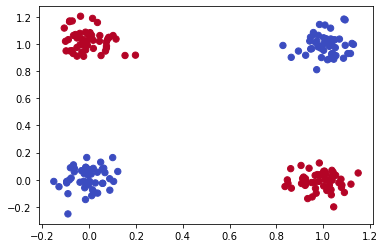

In [8]:
plt.scatter(X[:,0], X[:,1], c=Y, s=40, cmap='coolwarm')
plt.show()

You have two numpy arrays:
 - `X` contains the samples
 - `Y` contains the labels (red: 0, blue: 1).

Lets first get a better sense of what our data is like. 

### Exercise 

> **How many training examples do you have? In addition, what is the `shape` of the variables `X` and `Y`?**

*Hint*: How do you get the shape of a numpy array? [(help)](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.shape.html)

In [12]:
shape_X = X.shape
shape_Y = Y.shape
n_samples = len(X)

print ('The shape of X is: ' + str(shape_X))
print ('The shape of Y is: ' + str(shape_Y))
print ('I have {:d} training examples!'.format(n_samples))

The shape of X is: (200, 2)
The shape of Y is: (200,)
I have 200 training examples!


In [13]:
# If this cell raises an error, your solution is *NOT* correct

assert shape_X == (200,2)
assert shape_Y == (200,)
assert n_samples == 200

## 2.1 - Logistic Regression

Let's see how logistic regression performs on this problem. To do so, you can use the functions from the previous assignments. Run the code below.

In [14]:
def plot_decision_boundary(X, y, prediction):
    
    # Set min and max values and give it some padding
    x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
    y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
    h = 0.05
    
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Predict the function value for the whole grid
    Z = prediction(grid) > 0.5
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    plt.ylabel('$x_2$', fontsize=14)
    plt.xlabel('$x_1$', fontsize=14)
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='coolwarm')
    return


def logistic_prediction(w, x):
    wx = w[0] + x @ w[1:]
    s  = 1 / (1 + np.exp(-wx))
    return s

Now, you can visualize the decision boundary for some fixed values of $w=[w_0, w_1, w_2]^\top$.

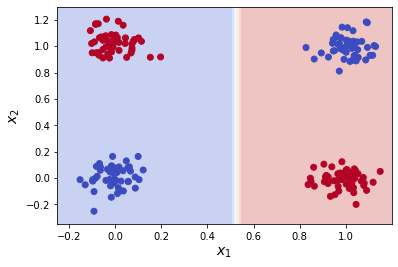

In [15]:
w = np.array([-0.5, 1, 0])

plot_decision_boundary(X, Y, lambda x: logistic_prediction(w,x))

### Exercise 

> **Find the values of $w=[w_0, w_1, w_2]^\top$ that allow the logistic classifier to mimic a logical "AND" function (defined below).**

<table style="width:10%">
  
  <tr>
    <th>x1</th>
    <th>x2</th> 
    <th>AND</th>
  </tr>
  
  <tr>
    <td>0</td>
    <td>0</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>0</td>
    <td>1</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>0</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>1</td> 
    <td>1</td> 
  </tr>
  
</table>

*Hint:* Note that the points are scattered into 4 distinct groups. 
- A group is centered in the position $(x_1,x_2) = (0,0)$
- A group is centered in the position $(x_1,x_2) = (0,1)$
- A group is centered in the position $(x_1,x_2) = (1,0)$
- A group is centered in the position $(x_1,x_2) = (1,1)$

The above table asks you to build a classifier such that the points centered at (0,0) are classified in the class 0, the points centered at (0,1) are classified in the class 0, the points centered at (1,0) are classified in the class 0, and finally the points centered at (1,1) are classified in the class 1. 

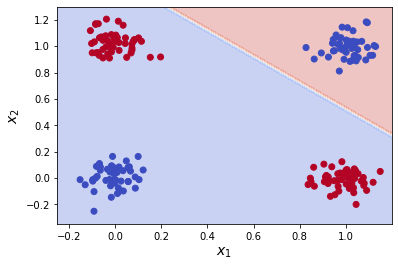

In [40]:
w = np.array([-30,20,20])  # <-- change these values


# show bondary
plot_decision_boundary(X, Y, lambda x: logistic_prediction(w,x))

In [41]:
# If this cell raises an error, your solution is *NOT* correct

assert logistic_prediction(w,[[0,0]]) < 0.5
assert logistic_prediction(w,[[0,1]]) < 0.5
assert logistic_prediction(w,[[1,0]]) < 0.5
assert logistic_prediction(w,[[1,1]]) > 0.5

### Exercise 

> **Find the values of $w=[w_0, w_1, w_2]^\top$ that allow the logistic classifier to mimic a logical "OR" function (defined below).**

<table style="width:10%">
  
  <tr>
    <th>x1</th>
    <th>x2</th> 
    <th>OR</th>
  </tr>
  
  <tr>
    <td>0</td>
    <td>0</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>0</td>
    <td>1</td> 
    <td>1</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>0</td> 
    <td>1</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>1</td> 
    <td>1</td> 
  </tr>
  
</table>

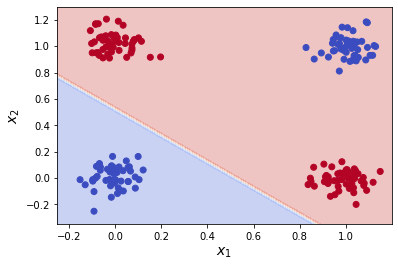

In [42]:
w = np.array([-10,20,20])  # <-- change these values


# show bondary
plot_decision_boundary(X, Y, lambda x: logistic_prediction(w,x))

In [43]:
# If this cell raises an error, your solution is *NOT* correct

assert logistic_prediction(w,[[0,0]]) < 0.5
assert logistic_prediction(w,[[0,1]]) > 0.5
assert logistic_prediction(w,[[1,0]]) > 0.5
assert logistic_prediction(w,[[1,1]]) > 0.5

### Exercise 

> **Find the values of $w=[w_0, w_1, w_2]^\top$ that allow the logistic classifier to mimic a logical "NOR" function (defined below).**

<table style="width:10%">
  
  <tr>
    <th>x1</th>
    <th>x2</th> 
    <th>NOR</th>
  </tr>
  
  <tr>
    <td>0</td>
    <td>0</td> 
    <td>1</td> 
  </tr>
  
  <tr>
    <td>0</td>
    <td>1</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>0</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>1</td> 
    <td>0</td> 
  </tr>
  
</table>

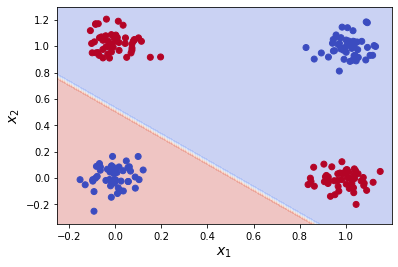

In [53]:
w = np.array([10,-20,-20])  # <-- change these values


# show bondary
plot_decision_boundary(X, Y, lambda x: logistic_prediction(w,x))

In [79]:
# If this cell raises an error, your solution is *NOT* correct

assert logistic_prediction(w,[[0,0]]) > 0.5
assert logistic_prediction(w,[[0,1]]) < 0.5
assert logistic_prediction(w,[[1,0]]) < 0.5
assert logistic_prediction(w,[[1,1]]) < 0.5

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## 2.2 - Network of logistic units

The dataset is not linearly separable, so it is impossible for logistic regression to correctly classify all samples. Hopefully a network of logistic units will do better. Let's try this now!

### Exercise 

> **Implement a function `network_prediction()` that evaluates the output of the following 2-layer network.**

$$
\begin{aligned}
a_1 &= {\sf sigmoid}\big(w_0^{(0)} + w_1^{(0)} x_1 + w_2^{(0)} x_2\big)\\[0.5em]
a_2 &= {\sf sigmoid}\big(w_0^{(1)} + w_1^{(1)} x_1 + w_2^{(1)} x_2\big)\\[0.5em]
y   &= {\sf sigmoid}\big(w_0^{(2)} + w_1^{(2)} a_1 + w_2^{(2)} a_2\big)\\[0.5em]
\end{aligned}
$$

*Instructions*: The code must be vectorized. To this end, the parameters are stored in a matrix $W\in\mathbb{R}^{3 \times 3}$

$$
W 
= 
\begin{bmatrix}
| & | & |\\[-1em]
{\rm w}^{(0)} & {\rm w}^{(1)} & {\rm w}^{(2)}\\[-1em]
| & | & |\\
\end{bmatrix}
=
\begin{bmatrix}
w_0^{(0)} & w_0^{(1)} & w_0^{(2)}\\
w_1^{(0)} & w_1^{(1)} & w_1^{(2)}\\
w_2^{(0)} & w_2^{(1)} & w_2^{(2)}
\end{bmatrix}
$$

The observations are stored into a matrix $X \in \mathbb{R}^{N\times 2}$

$$ 
X = \begin{bmatrix}
\_\!\_\; {{\rm x}^{(1)}}^\top \_\!\_ \\
\vdots\\
\_\!\_\; {{\rm x}^{(N)}}^\top \_\!\_ \\
\end{bmatrix} 
= \begin{bmatrix}
x_1^{(1)} & x_2^{(1)} \\
\vdots&\vdots\\
x_1^{(N)} & x_2^{(N)} \\
\end{bmatrix} 
$$


**Hint**: You may find useful the function `logistic_prediction()` to evaluate the single logistic units. Also, you need to concatenate the hidden-layer outputs `a1` and `a2` before evaluating the network output `y`. You can do this with the numpy function `np.stack(...)` [(read the doc)](https://docs.scipy.org/doc/numpy/reference/generated/numpy.stack.html).

In [66]:
def network_prediction(w, x):
    """Calculates the network prediction for each row of the input x.
     
    Arguments:
    w -- A numpy vector of shape (Q+1,3)
    x -- A numpy matrix of shape ( N, Q)

    Returns:
    s -- A numpy vector of shape (N,)
    """
        
    # Evaluate the 1st unit in the hidden layer
    a1 = logistic_prediction(w[:,0],[x[i] for i in range(len(x))])

    # Evaluate the 2nd unit in the hidden layer
    a2 = logistic_prediction(w[:,1],[x[i] for i in range(len(x))])
    
    # Evaluate the 3rd unit in the output layer
    a = np.stack([a1, a2], axis=1)
    y = logistic_prediction(w[:,2],a)
    
    return y

In [76]:
# If this cell raises an error, your solution is *NOT* correct

ww = np.array([[1,-2,-3],[-3,2,2],[-1,2,2]]).T
XX = np.array([[0.1,0.2,0.8,0.9],[-0.1,1.2,0.3,0.7]]).T
YY = network_prediction(ww, XX)

np.testing.assert_almost_equal(YY, [0.64459677, 0.49879594, 0.49622559, 0.55081771], decimal=4)

### Exercise 

> **Find the values of matrix $W$ that allow the neural network to mimic a logical "XNOR" function (defined below).**

<table style="width:14%">
  
  <tr>
    <th>x1</th>
    <th>x2</th> 
    <th>XNOR</th>
  </tr>
  
  <tr>
    <td>0</td>
    <td>0</td> 
    <td>1</td> 
  </tr>
  
  <tr>
    <td>0</td>
    <td>1</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>0</td> 
    <td>0</td> 
  </tr>
  
  <tr>
    <td>1</td>
    <td>1</td> 
    <td>1</td> 
  </tr>
  
</table>

*Hint*: The XNOR function can be expressed in terms of AND, NOR, and OR functions:

$$ x_1 \;{\sf XNOR}\; x_2 = (x_1 \;{\sf AND}\; x_2) \;{\sf OR}\; (x_1 \;{\sf NOR}\; x_2) $$

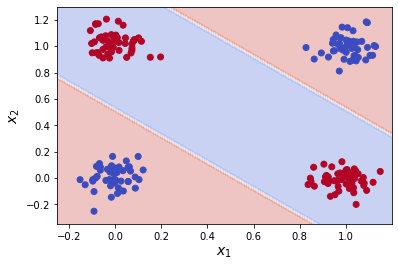

In [84]:
w = np.array([[-30,20,20],
              [10,-20,-20],
              [-10,20,20]]).T  # <-- change these values


# show bondary
plot_decision_boundary(X, Y, lambda x: network_prediction(w,x))

In [85]:
# If this cell raises an error, your solution is *NOT* correct

assert network_prediction(w,[[0,0]]) > 0.5
assert network_prediction(w,[[0,1]]) < 0.5
assert network_prediction(w,[[1,0]]) < 0.5
assert network_prediction(w,[[1,1]]) > 0.5

Neural networks are nonlinear models. Therefore, they can split the feature space using "complex" nonlinear decision boundaries. This leads to a more flexibile classifier than linear models.

# 3 - Neural network model

Now, let's build a full neural newtork with Keras. For this, let's change the dataset you will work on. The following code will load a 2-class dataset into variables `X` and `Y`.

In [86]:
X,Y = sklearn.datasets.make_moons(400, noise=0.05, random_state=0)

Visualize the dataset using matplotlib. Your goal is to build a model to fit this data using a neural network for **binary classification**.

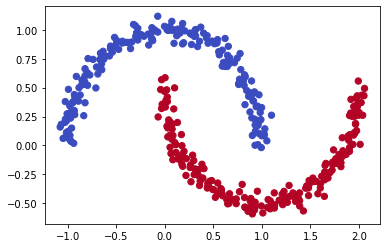

In [88]:
plt.scatter(X[:,0], X[:,1], c=Y, s=40, cmap='coolwarm')
plt.show()

### Exercise

> **How many training examples do you have? In addition, what is the `shape` of the variables `X` and `Y`?**

In [90]:
shape_X = X.shape
shape_Y = Y.shape
n_samples = len(X)

print ('The shape of X is: ' + str(shape_X))
print ('The shape of Y is: ' + str(shape_Y))
print ('I have {:d} training examples!'.format(n_samples))

The shape of X is: (400, 2)
The shape of Y is: (400,)
I have 400 training examples!


In [91]:
# If this cell raises an error, your solution is *NOT* correct

assert shape_X == (400,2)
assert shape_Y == (400,)
assert n_samples == 400

## 3.1 - One-layer neural network

Let's first see how a one-layer network  performs on this problem. Keras is very good for rapid prototyping. In just a short time, you will be able to build a model that achieves outstanding results.

To build a model, there are two steps in Keras:
 1. Stack the layers with the function `add()`
 2. Set the loss function with the function `compile()`.

The following code shows how to define a **binary logistic regression** model in Keras. In particular, note that:
 - the model contains a single layer with one sigmoid unit,
 - the loss function for binary classification is called `binary_crossentropy`,
 - the training is performed with a stochastic gradient optimizer called *Adam*. 
 
If you want to know more about these functions and their arguments, refer to the official Keras documentation [here](https://keras.io/models/model/) and [here](https://keras.io/optimizers/).

In [92]:
def onelayer_net(input_size, lr=0.1):
    
    # Define an empty model
    model = Sequential()
    
    # Add a single sigmoid unit
    model.add( Dense(units=1, activation='sigmoid', input_dim=input_size) )

    # Set the cost function
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
    
    return model

To train and test this model, there are three steps in Keras:
1. Create the model by calling the function above
2. Train the model by calling `model.fit(...)`
3. Evaluate the model by calling `model.evaluate(...)` or `model.predict(...)`

If you want to know more about these functions and their arguments, refer to the official [Keras documentation](https://keras.io/models/model/).

**Step 1** - Create the model

In [93]:
Q = X.shape[1] # number of features

net1 = onelayer_net(Q)

**Step 2** - Train the model

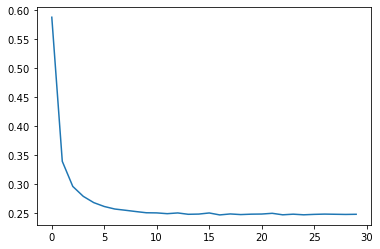

In [94]:
history = net1.fit(X, Y, epochs=30, verbose=0)

# ALWAYS plot the convergence curve!!!!
plt.plot(history.history['loss'])
plt.show()

**Step 3** - Evaluate the model

In [95]:
# Accuracy on training data
score = net1.evaluate(X, Y, verbose=0)

# Print accuracy
print ('One-layer network: %2.2f' % (100*score[1]) + '% ' + "of correctly labelled datapoints")

One-layer network: 88.50% of correctly labelled datapoints


To better understand the trained model, you can plot the decision boundary.

82/82 [==============================] - 0s 2ms/step


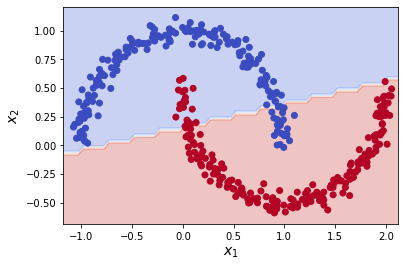

In [96]:
plot_decision_boundary(X, Y, net1.predict)

## 3.2 - Two-layer neural network

To improve the classification accuracy on the "moon" dataset, you are going to train a two-layer Neural Network.

### Exercise 

> **Using Keras, implement a function that builds a two-layer neural network for the task of binary classification.**

*Hint:* Keep in mind the following.
- The size of the input layer is given by the argument `input_size`
- The size of the hidden layer is given by the argument `hidden_size`
- The size of the output layer is **1** for binary classification
- The activation in the hidden layer is **relu**
- The activation in the output layer is **sigmoid** function
- The cost function is the **binary cross-entropy** function
- The optimizer is **Adam** and the learning rate is given by the argument `lr`

In [97]:
def twolayer_net(input_size, hidden_size, lr=0.001):
    
    model = Sequential()

    # 1. Add a layer with 'hidden_size' RELU units (In the first layer, you must also specify the input size)
    ... # YOUR CODE HERE
    
    # 2. Add a layer with one SIGMOID layer 
    ... # YOUR CODE HERE
    
    # 3. Set the binary cross-entropy loss, Adam optimizer, and the metric 'accuracy'
    ... # YOUR CODE HERE
    
    return model

In [98]:
# If this cell raises an error, your solution is *NOT* correct

net = twolayer_net(10, 20)

assert net.get_layer(index=0).input_shape[1]  == 10
assert net.get_layer(index=0).output_shape[1] == 20
assert net.get_layer(index=0).get_config()['activation'] == 'relu'
assert net.get_layer(index=1).output_shape[1] == 1
assert net.get_layer(index=1).get_config()['activation'] == 'sigmoid'

ValueError: Was asked to retrieve layer at index 0 but model only has 0 layers.

You can now train and test the two-layer network on the two-moon dataset.

**Note:** If the accuracy is not 100%, execute again the cell.

In [31]:
seed = 1
random.seed(seed)
np.random.seed(seed)
tensorflow.random.set_seed(seed)

# 1. Create the model
net2 = twolayer_net(2, 10, lr=0.01)

# 2. Train the model
history = net2.fit(X, Y, epochs=200, batch_size=40, verbose=0)

# 3. Evaluate the model
score = net2.evaluate(X, Y, verbose=0)

print ('Two-layer network: %2.2f' % (100*score[1]) + '% ' + "of correctly labelled datapoints")

# 4. Visual check
plt.figure(figsize=(10,4), tight_layout=True)
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.subplot(1,2,2)
plot_decision_boundary(X, Y, net2.predict)
plt.show()

## 3.3 Multilayer neural network

Now, let's try out a neural network with several layers. The function defined below allows you to define a neural network with an arbitrary number of layers and units, followed by an output layer for binary classification.

In [33]:
def multilayer_net(input_size, hidden_sizes, lr=0.001):
    
    model = Sequential()
    
    # Input layer
    model.add( Dense(units=hidden_sizes[0], activation='relu', input_dim=input_size) )
    
    # Middle layers
    for size in hidden_sizes[1:]:
        model.add( Dense(units=size, activation='relu') )
        
    # Output layer
    model.add( Dense(units=1, activation='sigmoid') )
    
    # Cost function
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
    
    return model

For example, this is how you can build a network with 3 hidden layers composed of 6, 4, and 2 RELU units, respectively. Then, it is the same as before to train and test the network.

**Note:** If the accuracy is not 100%, execute again the cell.

In [35]:
seed = 1
random.seed(seed)
np.random.seed(seed)
tensorflow.random.set_seed(seed)

# Create the model
net3 = multilayer_net(2, [6,4,2], lr=0.1)

# Train the model
history = net3.fit(X, Y, epochs=200, batch_size=40, verbose=0)

# Evaluate the model
score = net3.evaluate(X, Y, verbose=0)

print ('Multilayer network: %2.2f' % (100*score[1]) + '% ' + "of correctly labelled datapoints")

# Visual check
plt.figure(figsize=(10,4), tight_layout=True)
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.subplot(1,2,2)
plot_decision_boundary(X, Y, net3.predict)
plt.show()

**Interpretation**: Adding more layers/units to a neural netowrk increases its capacity to learn complex patterns from the data. With the two-moon dataset, you don't see much improvement, because the accuracy is already high with the 2-layer network. But if you switch to a more difficult dataset, you will see the difference. However, keep in mind that deep networks are more difficult to train and test, because: 
 - more training data is needed to prevent overfitting, 
 - it takes longer to learn the underlying patterns,
 - there are more hyper-parameters to tune.

## 3.4 - Performance on other datasets (optional)

If you want, you can try neural networks on a different dataset.

In [36]:
def load_flower_dataset():
    np.random.seed(1)
    m = 1000 # number of examples
    N = int(m/2) # number of points per class
    D = 2 # dimensionality
    X = np.zeros((m,D)) # data matrix where each row is a single example
    Y = np.zeros(m) # labels vector (0 for red, 1 for blue)
    a = 4 # maximum ray of the flower

    for j in range(2):
        ix = range(N*j,N*(j+1))
        t = np.linspace(j*3.12,(j+1)*3.12,N) + np.random.randn(N)*0.2 # theta
        r = a*np.sin(4*t) + np.random.randn(N)*0.2 # radius
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        Y[ix] = j

    return X, Y

X, Y = load_flower_dataset()

print ('The shape of X is: ' + str(X.shape))
print ('The shape of Y is: ' + str(Y.shape))
print ('Training examples: ' + str(X.shape[0]))

plt.scatter(X[:,0], X[:,1], c=Y, s=40, cmap='coolwarm', alpha=0.8)
plt.show()

# 4 - Neural networks for image classification

You will now build a neural network and apply it to "cat vs non-cat" classification.

**Problem Statement**: You are given a dataset containing:
  - a training set of images labelled as cat (1) or non-cat (0)
  - a test set of images labelled as cat and non-cat
  - each image is of shape (64, 64, 3), where 3 is for the RGB channels.

Let's get more familiar with the dataset. Load the data by running the cell below.

In [37]:
# Loading the data (cat/non-cat)
import h5py
    
train_dataset = h5py.File('lab03_data/train_catvnoncat.h5', "r")
train_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
train_y = np.array(train_dataset["train_set_y"][:]) # your train set labels

test_dataset = h5py.File('lab03_data/test_catvnoncat.h5', "r")
test_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
test_y = np.array(test_dataset["test_set_y"][:]) # your test set labels

classes = np.array(test_dataset["list_classes"][:]) # the list of classes

We added "_orig" at the end of image datasets because we are going to preprocess them. After preprocessing, we will end up with `train_x` and `test_x` (the labels `train_y` and `test_y` don't need any preprocessing).

Each line of your `train_x_orig` and `test_x_orig` is an array representing an image. You can visualize an example by running the following code. Feel free also to change the `index` value and re-run to see other images. 

In [38]:
index = 10

print ("It's a " + classes[train_y[index]].decode("utf-8") +  " picture (" + "y = " + str(train_y[index]) + ")")

plt.imshow(train_x_orig[index])
plt.axis('off')
plt.show()

Many software bugs in machine learning come from having matrix/vector dimensions that don't fit. If you can keep your matrix/vector dimensions straight you will go a long way toward eliminating many bugs. The code below prints the values for:
   - `m_train` (number of training examples)
   - `m_test` (number of test examples)
   - `num_px` (height/width of a training image).

In [39]:
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

One common preprocessing step in machine learning is to center and standardize your dataset, meaning that you substract the mean of the whole numpy array from each example, and then divide each example by the standard deviation of the whole numpy array. But for picture datasets, it is simpler and more convenient and works almost as well to just divide every row of the dataset by 255 (the maximum value of a pixel channel).

A standard multilayer network requires an additional preprocessing step, which is to reshape the images into vectors, as shown in the figure below. 

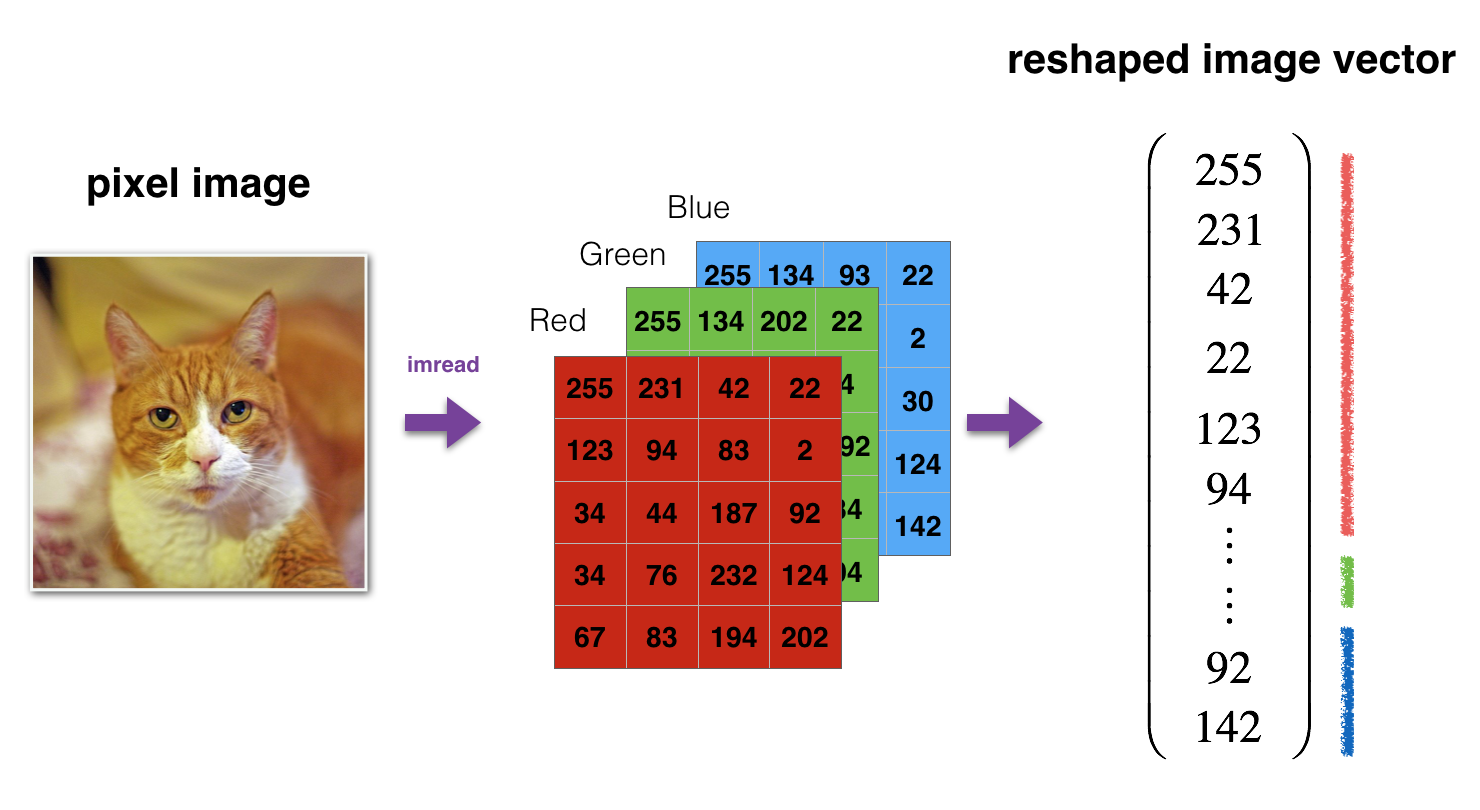

In [40]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1)
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1)

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten / 255.
test_x = test_x_flatten / 255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

### Common pitfall 

An important point to make about preprocessing is that any statistics (e.g., the data mean) must only be computed on the training data, and then applied to the validation / test data. For example, computing the mean and subtracting it from every image across the entire dataset and then splitting the data into train/test splits would be a mistake. Instead, the mean must be computed only over the training data and then subtracted equally from all splits (train/test).

## 4.1 - Training a small network

### Exercise

> **Build a two-layer network, and fit it on the training set (`train_x` - `train_y`).**

*Hints:* Make sure that the plot descreases and eventually gets "flat" after enough epochs. 
 - If it's not converging, try to lower the learning rate. 
 - If it's decreasing too slowly, try to raise the learning rate, and/or increase the number of epochs. 

Also, use a small value for the parameter `batch_size` (between 10 and 50).

In [43]:
seed = 12
random.seed(seed)
np.random.seed(seed)
tensorflow.random.set_seed(seed)

net = Sequential()
... # YOUR CODE HERE
... # YOUR CODE HERE
... # YOUR CODE HERE

history = None # YOUR CODE HERE

plt.plot(history.history['loss'][5:])
plt.show()

### Exercise

> **Compute the accuracy of your network on the training set (`train_x`, `train_y`) and the test set (`test_x`, `test_y`).**

In [44]:
train_score = None # YOUR CODE HERE
test_score = None # YOUR CODE HERE

print ('Accuracy on train: %2.2f' % (100*train_score[1]) + '% ')
print ('Accuracy on test : %2.2f' % (100* test_score[1]) + '% ')

### Exercise

> **Tune the hyper-parameters of your network: hidden layer size, learning rate, epochs, batch size**.

*Hint:* When tuning the hyper-parameters, you should look at the performace on the test set, not the training set.

## 4.2 - Training a deep network

### Exercise 

> **Build a multilayer network, fit it on the training set (`train_x` - `train_y`), compute the accuracy on the training set and the test set (`test_x` - `test_y`).**
 
*Hint:* Start with a small network and make sure that it learns correctly (i.e., the cost function gets "flat"). To this end, you may probably need to increase the number of epochs to 500, and decrease the step-size to $10^{-5}$. Don't worry about the other hyper-parameters: you will tune them in the next exercise.

In [47]:
seed = 7
random.seed(seed)
np.random.seed(seed)
tensorflow.random.set_seed(seed)

net = Sequential()

# YOUR CODE HERE


print ('Accuracy on train: %2.2f' % (100*train_score[1]) + '% ')
print ('Accuracy on test : %2.2f' % (100* test_score[1]) + '% ')

plt.plot(history.history['loss'])
plt.show()

### Exercise 

> **Find reasonable values for the number of hidden layers, and the size of each hidden layer.**

*Reminder:* When tuning the hyper-parameters, you should look at the performace on the test set, not the training set.

*Goal:* Between 70% and 80% accuracy on the test set.

##  4.3 - Results Analysis

Let's take a look at some images the multilayer network labeled incorrectly. This will show a few mislabeled images. 

In [92]:
def print_mislabeled_images(classes, X, y, p):
    """
    Plots images where predictions and truth were different.
    X -- dataset
    y -- true labels
    p -- predictions
    """    
    mislabeled_indices, = np.where(p.squeeze() != y)
    plt.figure(figsize=(20, 8))
    num_images = min(10, len(mislabeled_indices))
    for i in range(num_images):
        index = mislabeled_indices[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[index,:].reshape(64,64,3), interpolation='nearest')
        plt.axis('off')
        plt.title("Prediction: " + classes[int(p[index])].decode("utf-8") + " \n Class: " + classes[y[index]].decode("utf-8"))
    plt.show()

In [93]:
print_mislabeled_images(classes, test_x, test_y, net.predict(test_x)>0.5)

**A few type of images the model tends to do poorly on include:** 
- Cat body in an unusual position
- Cat appears against a background of a similar color
- Unusual cat color and species
- Camera Angle
- Brightness of the picture
- Scale variation (cat is very large or small in image) 